## Setting up Trident enviroment in colab

#### If python is >= 3.12 (choose older setup of the runtime)

In [ ]:
# 1. Update and install Python 3.11
!sudo apt-get update -y
!sudo apt-get install python3.11 python3.11-dev python3.11-distutils libpython3.11-dev

# 2. Set it as the default python3
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.11 2

# 3. Select Python 3.11 (Type '2' when prompted)
!sudo update-alternatives --config python3

# 4. Re-install pip for the new version
!curl -sS https://bootstrap.pypa.io/get-pip.py | python3.11

2
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:5 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:6 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,480 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,955 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd6

In [ ]:
# Ensure torch and torchvision are installed for python 3.11 and compatible numpy
!python3.11 -m pip uninstall -y torch torchvision torchaudio numpy
!python3.11 -m pip install numpy==1.26.4
!python3.11 -m pip install torch==2.1.0 torchvision==0.16.0 --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.1.0+cu118
Uninstalling torch-2.1.0+cu118:
  Successfully uninstalled torch-2.1.0+cu118
Found existing installation: torchvision 0.16.0+cu118
Uninstalling torchvision-0.16.0+cu118:
  Successfully uninstalled torchvision-0.16.0+cu118
Found existing installation: numpy 2.4.3
Uninstalling numpy-2.4.3:
  Successfully uninstalled numpy-2.4.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 71.4 MB/s  0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
segmentation-models-pytorch 0.5.0 requires torch>=1.8, which is not installed.
segmentation-models-pytorch 0.5.0 requires torchvision>=0.9, which is not installed.
trident 0.2.4 requires torch, which is not installed.
trident 0.2.4 requires torchvision, which is not installed.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 wh

#### Else:

In [ ]:
!python --version

Python 3.11.13


In [ ]:
!git clone https://github.com/mahmoodlab/TRIDENT.git

Cloning into 'TRIDENT'...
remote: Enumerating objects: 1779, done.
remote: Counting objects: 100% (901/901), done.
remote: Compressing objects: 100% (327/327), done.
remote: Total 1779 (delta 721), reused 574 (delta 574), pack-reused 878 (from 2)
Receiving objects: 100% (1779/1779), 3.33 MiB | 9.31 MiB/s, done.
Resolving deltas: 100% (1162/1162), done.


In [ ]:
!python -m pip install -e ./TRIDENT

Obtaining file:///content/TRIDENT
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 6.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the

In [ ]:
# Install openslide-tools and openslide-python
#!sudo apt-get update -y
#!sudo apt-get install openslide-tools
#!python -m pip install openslide-python
!python -m pip install openslide-python openslide-bin

In [ ]:
import sys

# The expected installation path for openslide-python
openslide_path = '/usr/local/lib/python3.11/dist-packages'

# Add the path to sys.path if it's not already there
if openslide_path not in sys.path:
    sys.path.insert(0, openslide_path)
    print(f"Added {openslide_path} to sys.path")
else:
    print(f"{openslide_path} is already in sys.path")

# Print sys.path to verify
print("Current sys.path:")
for path in sys.path:
    print(f"- {path}")


/usr/local/lib/python3.11/dist-packages is already in sys.path
Current sys.path:
- /content
- /env/python
- /usr/lib/python311.zip
- /usr/lib/python3.11
- /usr/lib/python3.11/lib-dynload
- 
- /usr/local/lib/python3.11/dist-packages
- /usr/lib/python3/dist-packages
- /usr/local/lib/python3.11/dist-packages/IPython/extensions
- /usr/local/lib/python3.11/dist-packages/setuptools/_vendor
- /root/.ipython


In [ ]:
!trident --help

usage: trident [-h] [--version] {batch,single,doctor,convert} ...

TRIDENT command-line interface.

positional arguments:
  {batch,single,doctor,convert}
    batch               Run batch slide processing (wrapper around
                        run_batch_of_slides).
    single              Run single slide processing (wrapper around
                        run_single_slide).
    doctor              Run environment diagnostics (wrapper around trident-
                        doctor).
    convert             Convert images/WSIs to pyramidal TIFF with
                        AnyToTiffConverter.

options:
  -h, --help            show this help message and exit
  --version             show program's version number and exit


In [ ]:
import os
import sys
import torch
import h5py
from PIL import Image
import geopandas as gpd
from IPython.display import display
from huggingface_hub import snapshot_download

# Add the TRIDENT directory to sys.path
TRIDENT_PATH = "/content/TRIDENT"
if TRIDENT_PATH not in sys.path:
    sys.path.insert(0, TRIDENT_PATH)

from trident.wsi_objects.OpenSlideWSI import OpenSlideWSI
from trident.segmentation_models import segmentation_model_factory
from trident.patch_encoder_models import encoder_factory

### Mounting drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

## Running segmentation, patching and feature extraction for 1 test slide

### Segmentation

In [ ]:
!mkdir data_wsi
!mkdir sample_results

In [ ]:
import openslide_bin, os

# Find the actual package location
print("openslide_bin location:", openslide_bin.__file__)
print("\nContents:")
for f in os.listdir(os.path.dirname(openslide_bin.__file__)):
    print(" ", f)

openslide_bin location: /usr/local/lib/python3.11/dist-packages/openslide_bin/__init__.py

Contents:
  py.typed
  __init__.py
  __pycache__
  libopenslide.so.1


In [ ]:
import openslide_bin, ctypes, os

lib_dir = os.path.dirname(openslide_bin.__file__)
lib_path = os.path.join(lib_dir, 'libopenslide.so.1')

ctypes.CDLL(lib_path)
print("Loaded:", lib_path)

import openslide
print("OpenSlide library version:", openslide.__library_version__)

Loaded: /usr/local/lib/python3.11/dist-packages/openslide_bin/libopenslide.so.1
OpenSlide library version: 4.0.0


In [ ]:
import os

wsi_path = "/content/drive/MyDrive/010426_tatiana_wsi/119 ETS2 KO.svs"
print("exists:", os.path.exists(wsi_path))
print("size:", os.path.getsize(wsi_path) / 1024**2, "MB")

# Also list the folder to see exact filenames
folder = "/content/drive/MyDrive/010426_tatiana_wsi/"
print("\nFiles in folder:")
for f in os.listdir(folder):
    print(f" '{f}'")

exists: True
size: 1292.1899843215942 MB

Files in folder:
 '121 KO.svs'
 '103 KO ETS2.svs'
 '119 ETS2 KO.svs'
 '120 Ctrl.svs'


In [ ]:
import openslide
slide = openslide.OpenSlide(wsi_path)
print("dimensions:", slide.dimensions)

dimensions: (103583, 45032)


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

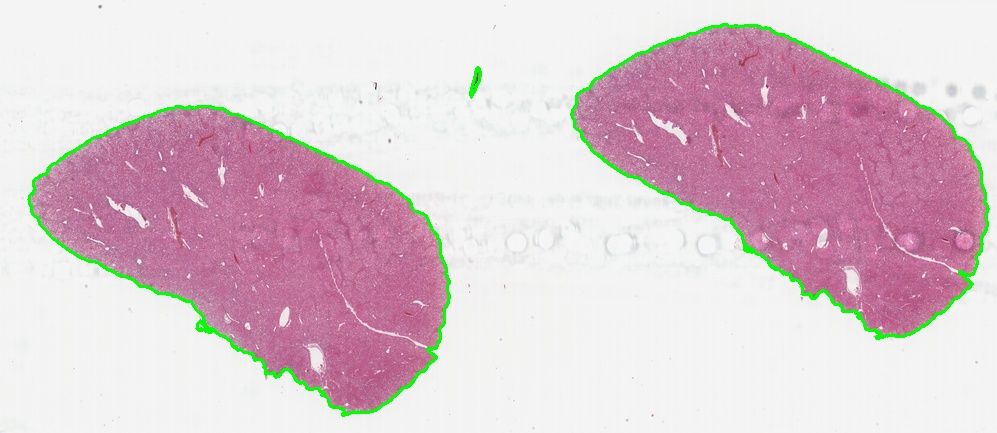

,tissue_id,geometry
0,0,"POLYGON ((20759 33210, 20759 33233, 20759 3325..."
1,1,"POLYGON ((20737 11010, 20714 11032, 20692 1103..."
2,2,"POLYGON ((49534 7024, 49512 7047, 49512 7069, ..."
3,3,"POLYGON ((75000 2566, 74977 2589, 74955 2589, ..."


In [ ]:
# a. Download a WSI

local_wsi_dir = "/content/drive/MyDrive/010426_tatiana_wsi/"
OUTPUT_DIR = "sample_results/"
WSI_FNAME = "119 ETS2 KO.svs"
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
os.makedirs(OUTPUT_DIR, exist_ok=True)

wsi_path = os.path.join(local_wsi_dir, WSI_FNAME)
slide = OpenSlideWSI(wsi_path)

# c. Run segmentation
segmentation_model = segmentation_model_factory("hest")
geojson_contours = slide.segment_tissue(segmentation_model=segmentation_model, target_mag=10, job_dir=OUTPUT_DIR, device=DEVICE)

# d. Visualize contours
contour_image = Image.open(os.path.join(OUTPUT_DIR, 'contours', WSI_FNAME.replace('.svs', '.jpg')))
display(contour_image)

# e. Check contours saved into GeoJSON with GeoPandas
gdf = gpd.read_file(geojson_contours)
gdf.head(n=10)

### Tissue coordinate extraction

We are patching the whole-slide image into non-overlapping patches of size 256x256 at 20x magnification (0.5 um/px).

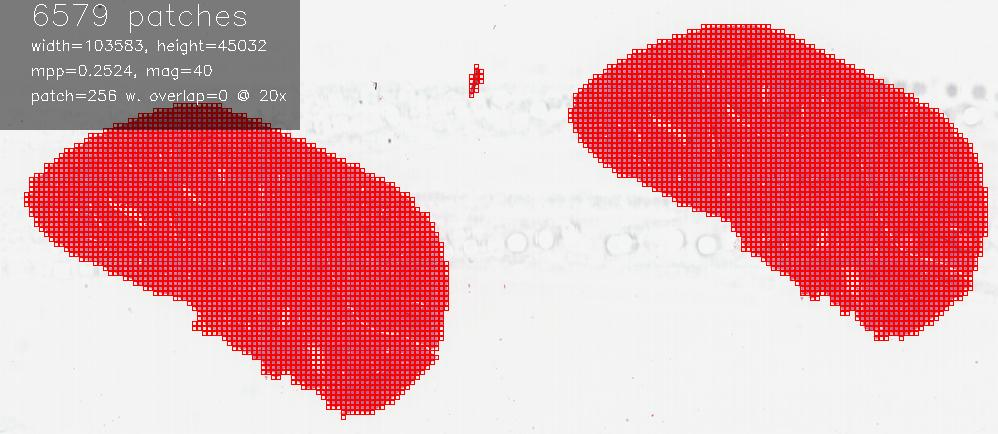

Contents and Attributes in patch coords file:
Object: coords
  Attribute - level0_height: 45032
  Attribute - level0_magnification: 40
  Attribute - level0_width: 103583
  Attribute - name: 119 ETS2 KO
  Attribute - overlap: 0
  Attribute - patch_size: 256
  Attribute - patch_size_level0: 512
  Attribute - savetodir: sample_results/
  Attribute - target_magnification: 20


In [ ]:
TARGET_MAG = 20
PATCH_SIZE = 256

# a. Run patch coordinate extraction
coords_path = slide.extract_tissue_coords(
    target_mag=TARGET_MAG,
    patch_size=PATCH_SIZE,
    save_coords=OUTPUT_DIR
)

# b. Visualize
viz_coords_path = slide.visualize_coords(
    coords_path=coords_path,
    save_patch_viz=os.path.join(OUTPUT_DIR, "visualization")
)
display(Image.open(viz_coords_path))

# c. Inspect h5 with patch coordinates
def print_attrs(name, obj):
    print(f"Object: {name}")
    for key, value in obj.attrs.items():
        print(f"  Attribute - {key}: {value}")

with h5py.File(coords_path, 'r') as h5_file:
    print("Contents and Attributes in patch coords file:")
    h5_file.visititems(print_attrs)

### Patch feature extraction with the UNI model

In [ ]:
PATCH_ENCODER = "uni_v1" # Visit the factory or check the README for a list of all available models

# a. Instantiate UNI model using the factory
encoder = encoder_factory(PATCH_ENCODER)
encoder.eval()
encoder.to(DEVICE)

# b. Run UNI feature extraction
features_dir = os.path.join(OUTPUT_DIR, f"features_{PATCH_ENCODER}")
feats_path = slide.extract_patch_features(
    patch_encoder=encoder,
    coords_path=coords_path,
    save_features=features_dir,
    device=DEVICE
)

# c. Inspect h5 with patch features
with h5py.File(feats_path, 'r') as h5_file:
    print("Contents and Attributes in feats file:")
    h5_file.visititems(print_attrs)

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Contents and Attributes in feats file:
Object: coords
  Attribute - level0_height: 45032
  Attribute - level0_magnification: 40
  Attribute - level0_width: 103583
  Attribute - name: 119 ETS2 KO
  Attribute - overlap: 0
  Attribute - patch_size: 256
  Attribute - patch_size_level0: 512
  Attribute - savetodir: sample_results/
  Attribute - target_magnification: 20
Object: features
  Attribute - encoder: uni_v1
  Attribute - name: 119 ETS2 KO
  Attribute - savetodir: sample_results/features_uni_v1


### Patch level clusteing using kmeans

Loaded 6579 features.
Performing MiniBatchKMeans clustering with 5 clusters...
Clustering complete.
Cluster visualization saved to sample_results/kmeans_clusters_overlay_5.png


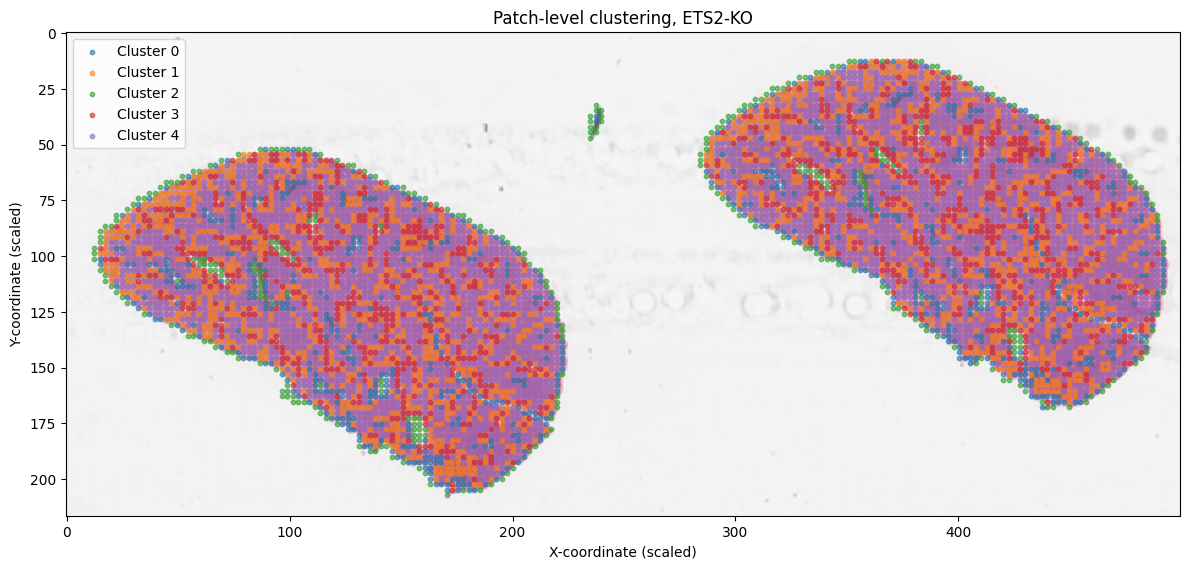

In [ ]:
import numpy as np
import h5py
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
from PIL import Image
import os
import openslide
from openslide import OpenSlide

# Assuming slide and feats_path are already defined from your previous code
# slide = OpenSlideWSI(wsi_path)
# feats_path = os.path.join(OUTPUT_DIR, f"features_{PATCH_ENCODER}", "features.h5")

# Load features from the H5 file
with h5py.File(feats_path, 'r') as f:
    features = f['features'][:]
    coords = f['coords'][:] # Assuming coords are also saved in the features H5, or load from coords_path if not.

print(f"Loaded {len(features)} features.")

# Define the number of clusters
n_clusters = 5 # You can adjust this number

# Perform K-Means clustering
print(f"Performing MiniBatchKMeans clustering with {n_clusters} clusters...")
kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42, batch_size=256, n_init=10)
cluster_labels = kmeans.fit_predict(features)
print("Clustering complete.")

# Get the WSI thumbnail
thumbnail_size = (500, 500) # Adjust as needed
wsi_path = os.path.join(local_wsi_dir, WSI_FNAME)
slide_os = openslide.OpenSlide(wsi_path)
thumbnail = slide_os.get_thumbnail(thumbnail_size)
thumbnail = np.array(thumbnail)
slide_os.close()

# Create a scatter plot of the clusters overlaid on the thumbnail
plt.figure(figsize=(12, 12))
plt.imshow(thumbnail)

# Scale patch coordinates to thumbnail dimensions
# Get the original WSI dimensions at level 0
# CORRECTED LINE:
wsi_width, wsi_height = slide.dimensions # Use slide.dimensions directly from the OpenSlideWSI object

# Calculate scaling factors
x_scale = thumbnail.shape[1] / wsi_width
y_scale = thumbnail.shape[0] / wsi_height

# Adjust patch coordinates to the thumbnail scale
scaled_coords_x = coords[:, 0] * x_scale
scaled_coords_y = coords[:, 1] * y_scale

# Plot each cluster
for i in range(n_clusters):
    cluster_coords = coords[cluster_labels == i]
    scaled_cluster_coords_x = scaled_coords_x[cluster_labels == i]
    scaled_cluster_coords_y = scaled_coords_y[cluster_labels == i]
    plt.scatter(scaled_cluster_coords_x, scaled_cluster_coords_y, s=10, label=f'Cluster {i}', alpha=0.6)

plt.title(f'Patch-level clustering, ETS2-KO')
plt.xlabel('X-coordinate (scaled)')
plt.ylabel('Y-coordinate (scaled)')
plt.legend()
plt.tight_layout()

# You can also save the plot
plot_output_path = os.path.join(OUTPUT_DIR, f"kmeans_clusters_overlay_{n_clusters}.png")
plt.savefig(plot_output_path)
print(f"Cluster visualization saved to {plot_output_path}")
plt.show()

## Running this code for all slides

Saving results to Drive in real time (Colab Pro+ should run in the background..)

In [ ]:
!sudo apt install tree
!tree "/content/drive/MyDrive/WSI_Processing_Results/103 KO ETS2"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 42 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (67.8 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tree.
(Reading database ... 122354 files and directories currently instal

In [ ]:
import os
import torch
import h5py
import geopandas as gpd
from PIL import Image
from trident.wsi_objects.OpenSlideWSI import OpenSlideWSI
from trident.segmentation_models import segmentation_model_factory
from trident.patch_encoder_models import encoder_factory
from datetime import datetime

# --- Configuration ---
INPUT_WSI_DIR = "/content/drive/MyDrive/010426_tatiana_wsi" # Your folder with SVS files
OUTPUT_ROOT_DIR = "/content/drive/MyDrive/WSI_Processing_Results" # Base folder on Google Drive for all outputs
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

TARGET_MAG_SEGMENTATION = 10
TARGET_MAG_PATCHING = 20
PATCH_SIZE = 256
SEGMENTATION_MODEL = "hest" # 'hest', 'deepflash', or 'hovernet'
PATCH_ENCODER = "uni_v1" # 'uni_v1', 'ctranspath', 'resnet50' etc.

# Create root output directory if it doesn't exist
os.makedirs(OUTPUT_ROOT_DIR, exist_ok=True)
print(f"Output root directory: {OUTPUT_ROOT_DIR}")

# --- Helper Functions (Optional, for better organization) ---
def print_attrs(name, obj):
    """Helper to print H5 file attributes."""
    print(f"  Object: {name}")
    for key, value in obj.attrs.items():
        print(f"    Attribute - {key}: {value}")

def process_wsi(wsi_path, output_dir_for_wsi):
    """
    Processes a single WSI: segmentation, patching, feature extraction.
    Saves all intermediate and final results to the specified output directory.
    """
    wsi_fname = os.path.basename(wsi_path)
    wsi_stem = os.path.splitext(wsi_fname)[0]
    print(f"\n--- Processing {wsi_fname} ---")

    # Create a specific output directory for this WSI
    os.makedirs(output_dir_for_wsi, exist_ok=True)
    print(f"Results for {wsi_fname} will be saved in: {output_dir_for_wsi}")

    # Initialize WSI object. This should only happen ONCE for the slide within this function.
    slide = None # Initialize slide object
    try:
        slide = OpenSlideWSI(wsi_path)
        print(f"Successfully opened WSI: {wsi_path}")
    except Exception as e:
        print(f"ERROR: Could not open WSI {wsi_fname} at start. Skipping. Error: {e}")
        return

    # --- 1. Segmentation ---
    print("Step 1/3: Running segmentation...")
    segmentation_output_dir = os.path.join(output_dir_for_wsi, "segmentation")
    os.makedirs(segmentation_output_dir, exist_ok=True)

    geojson_contours_path_expected = os.path.join(segmentation_output_dir, 'contours_geojson', f'{wsi_stem}.geojson')
    contour_image_path_expected = os.path.join(segmentation_output_dir, 'contours', f'{wsi_stem}.jpg')
    thumbnail_image_path_expected = os.path.join(segmentation_output_dir, 'thumbnails', f'{wsi_stem}.jpg')

    if (os.path.exists(geojson_contours_path_expected) and
        os.path.exists(contour_image_path_expected) and
        os.path.exists(thumbnail_image_path_expected)):
        print(f"Segmentation results for {wsi_fname} already exist. Skipping segmentation.")
    else:
        try:
            segmentation_model = segmentation_model_factory(SEGMENTATION_MODEL)
            geojson_contours = slide.segment_tissue(
                segmentation_model=segmentation_model,
                target_mag=TARGET_MAG_SEGMENTATION,
                job_dir=segmentation_output_dir,
                device=DEVICE
            )
            print(f"Segmentation complete. GeoJSON contours saved to: {geojson_contours}")
            if os.path.exists(contour_image_path_expected):
                print(f"Contour visualization saved to: {contour_image_path_expected}")
            if os.path.exists(thumbnail_image_path_expected):
                print(f"Thumbnail visualization saved to: {thumbnail_image_path_expected}")
            else:
                print("Warning: Some segmentation visualization JPGs not found as expected.")
        except Exception as e:
            print(f"ERROR: Segmentation failed for {wsi_fname}. Error: {e}")
            return

    # --- 2. Patch Coordinate Extraction ---
    print("Step 2/3: Checking patch coordinate extraction results...")
    patch_coords_output_dir = os.path.join(output_dir_for_wsi, "patch_coords")
    os.makedirs(patch_coords_output_dir, exist_ok=True)

    existing_coords_h5_path = os.path.join(
        patch_coords_output_dir,
        "patches",
        f'{wsi_stem}_patches.h5'
    )
    existing_viz_coords_jpg_path = os.path.join(patch_coords_output_dir, f'{wsi_stem}.jpg')

    coords_path_for_next_step = None

    if os.path.exists(existing_coords_h5_path) and os.path.exists(existing_viz_coords_jpg_path):
        print(f"Patch coordinates and visualization for {wsi_fname} already exist. Skipping coordinate extraction.")
        coords_path_for_next_step = existing_coords_h5_path
    else:
        print(f"Patch coordinates for {wsi_fname} do not exist (or visualization missing), performing extraction...")
        try:
            coords_path_returned = slide.extract_tissue_coords(
                target_mag=TARGET_MAG_PATCHING,
                patch_size=PATCH_SIZE,
                save_coords=patch_coords_output_dir
            )
            print(f"Patch coordinates saved to: {coords_path_returned}")
            coords_path_for_next_step = coords_path_returned

            viz_coords_path = slide.visualize_coords(
                coords_path=coords_path_for_next_step,
                save_patch_viz=patch_coords_output_dir,
            )
            print(f"Patch coordinate visualization saved to: {viz_coords_path}")
        except Exception as e:
            print(f"ERROR: Patch coordinate extraction failed for {wsi_fname}. Error: {e}")
            return

    if coords_path_for_next_step is None or not os.path.exists(coords_path_for_next_step):
        print(f"CRITICAL ERROR: Patch coordinate file {coords_path_for_next_step} does not exist for {wsi_fname} even after extraction attempt. Skipping feature extraction.")
        return

    # --- 3. Feature Extraction ---
    print(f"Step 3/3: Running feature extraction with {PATCH_ENCODER}...")
    features_output_dir = os.path.join(output_dir_for_wsi, f"features_{PATCH_ENCODER}")
    os.makedirs(features_output_dir, exist_ok=True)

    # Based on your tree, features are saved as {wsi_stem}.h5 directly in features_uni_v1
    feats_h5_path_expected = os.path.join(features_output_dir, f'{wsi_stem}.h5') # Corrected filename based on your tree

    if os.path.exists(feats_h5_path_expected):
        print(f"Features for {wsi_fname} with {PATCH_ENCODER} already exist at {feats_h5_path_expected}. Skipping feature extraction.")
    else:
        try:
            # Removed the re-initialization of slide here.
            # We'll rely on the slide object created at the very beginning.
            # If it fails, the initial WSI open was truly the problem.

            encoder = encoder_factory(PATCH_ENCODER)
            encoder.eval()
            encoder.to(DEVICE)

            # Check if the coords_path needs renaming for trident's extract_patch_features
            # This is the most common reason for the '_coords.h5' error.
            # If this is consistently failing with '_coords.h5' error, uncomment and use this logic.
            #
            # trident_expected_coords_suffix = '_coords.h5'
            # current_coords_suffix = os.path.splitext(coords_path_for_next_step)[1]
            #
            # if current_coords_suffix != trident_expected_coords_suffix:
            #     target_coords_path = os.path.join(
            #         os.path.dirname(coords_path_for_next_step),
            #         f'{wsi_stem}{trident_expected_coords_suffix}'
            #     )
            #     if not os.path.exists(target_coords_path):
            #         print(f"WARNING: Renaming patch coordinates from {os.path.basename(coords_path_for_next_step)} to {os.path.basename(target_coords_path)} for Trident compatibility.")
            #         os.rename(coords_path_for_next_step, target_coords_path)
            #         coords_path_for_next_step = target_coords_path
            #     else:
            #         # If _coords.h5 already exists, use it instead.
            #         print(f"NOTE: {os.path.basename(target_coords_path)} already exists. Using it for feature extraction.")
            #         coords_path_for_next_step = target_coords_path


            feats_path = slide.extract_patch_features(
                patch_encoder=encoder,
                coords_path=coords_path_for_next_step, # This is '/.../patches/{wsi_stem}_patches.h5'
                save_features=features_output_dir, # This is the base directory for {wsi_stem}.h5
                device=DEVICE
            )
            print(f"Features saved to: {feats_path}")

            with h5py.File(feats_path, 'r') as h5_file:
                print(f"  Inspecting {os.path.basename(feats_path)}:")
                h5_file.visititems(print_attrs)
        except Exception as e:
            print(f"ERROR: Feature extraction failed for {wsi_fname}. Error: {e}")
            return

    print(f"--- Finished processing {wsi_fname} ---")

# --- Main Script Execution ---
if __name__ == "__main__":
    print(f"Starting batch processing of WSIs from: {INPUT_WSI_DIR}")
    all_svs_files = [f for f in os.listdir(INPUT_WSI_DIR) if f.lower().endswith('.svs')]

    if not all_svs_files:
        print(f"No .svs files found in {INPUT_WSI_DIR}. Please check the path.")
    else:
        print(f"Found {len(all_svs_files)} .svs files.")

    for svs_file in sorted(all_svs_files):
        wsi_path = os.path.join(INPUT_WSI_DIR, svs_file)
        wsi_stem = os.path.splitext(svs_file)[0]
        output_dir_for_this_wsi = os.path.join(OUTPUT_ROOT_DIR, wsi_stem)

        process_wsi(wsi_path, output_dir_for_this_wsi)

    print("\nAll WSI files processed (or skipped if errors occurred or results existed).")

Output root directory: /content/drive/MyDrive/WSI_Processing_Results
Starting batch processing of WSIs from: /content/drive/MyDrive/010426_tatiana_wsi
Found 86 .svs files.

--- Processing 103 KO ETS2.svs ---
Results for 103 KO ETS2.svs will be saved in: /content/drive/MyDrive/WSI_Processing_Results/103 KO ETS2
Successfully opened WSI: /content/drive/MyDrive/010426_tatiana_wsi/103 KO ETS2.svs
Step 1/3: Running segmentation...
Segmentation results for 103 KO ETS2.svs already exist. Skipping segmentation.
Step 2/3: Checking patch coordinate extraction results...
Patch coordinates and visualization for 103 KO ETS2.svs already exist. Skipping coordinate extraction.
Step 3/3: Running feature extraction with uni_v1...
Features for 103 KO ETS2.svs with uni_v1 already exist at /content/drive/MyDrive/WSI_Processing_Results/103 KO ETS2/features_uni_v1/103 KO ETS2.h5. Skipping feature extraction.
--- Finished processing 103 KO ETS2.svs ---

--- Processing 119 ETS2 KO.svs ---
Results for 119 ETS2 K

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 269MB/s]


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

deeplabv3_seg_v4.ckpt:   0%|          | 0.00/486M [00:00<?, ?B/s]

ERROR: Segmentation failed for 2_11     1.svs. Error: Caught OpenSlideError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/content/TRIDENT/trident/wsi_objects/WSIPatcherDataset.py", line 15, in __getitem__
    tile, x, y = self.patcher[index]
                 ~~~~~~~~~~~~^^^^^^^
  File "/content/TRIDENT/trident/wsi_obj

...

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Features saved to: /content/drive/MyDrive/WSI_Processing_Results/39 C-R ETS2/features_uni_v1/39 C-R ETS2.h5
  Inspecting 39 C-R ETS2.h5:
  Object: coords
    Attribute - level0_height: 47762
    Attribute - level0_magnification: 40
    Attribute - level0_width: 127487
    Attribute - name: 39 C-R ETS2
    Attribute - overlap: 0
    Attribute - patch_size: 256
    Attribute - patch_size_level0: 512
    Attribute - savetodir: /content/drive/MyDrive/WSI_Processing_Results/39 C-R ETS2/patch_coords
    Attribute - target_magnification: 20
  Object: features
    Attribute - encoder: uni_v1
    Attribute - name: 39 C-R ETS2
    Attribute - savetodir: /content/drive/MyDrive/WSI_Processing_Results/39 C-R ETS2/features_uni_v1
--- Finished processing 39 C-R ETS2.svs ---

--- Processing 3_13     1.svs ---
Results for 3_13     1.svs will be saved in: /content/drive/MyDrive/WSI_Processing_Results/3_13     1
Successfully opened WSI: /content/drive/MyDrive/010426_tatiana_wsi/3_13     1.svs
Step 1/3: R

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

ERROR: Segmentation failed for 3_13     1.svs. Error: Caught OpenSlideError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/content/TRIDENT/trident/wsi_objects/WSIPatcherDataset.py", line 15, in __getitem__
    tile, x, y = self.patcher[index]
                 ~~~~~~~~~~~~^^^^^^^
  File "/content/TRIDENT/trident/wsi_obj

In [ ]:
OUTPUT_ROOT_DIR

'/content/drive/MyDrive/WSI_Processing_Results'